In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('flights.csv')
df.head()

,FLIGHT_DATE,FLIGHT_TIME,TIME_OF_DAY,AIRLINE_CD,FLIGHT_NO,DEPARTURE_STATION_CD,ARRIVAL_STATION_CD,ARRIVAL_COUNTRY,ARRIVAL_REGION,HAUL,AIRCRAFT_TYPE,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX
0,2025-09-02,14:19:00,Afternoon,BA,BA5211,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,10,38
1,2025-06-10,06:42:00,Morning,BA,BA7282,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,7,28
2,2025-10-27,15:33:00,Afternoon,BA,BA1896,LHR,FRA,Germany,Europe,SHORT,A320,0,17,163,0,11,40
3,2025-06-15,18:29:00,Evening,BA,BA5497,LHR,IST,Turkey,Europe,SHORT,A320,0,8,172,0,16,54
4,2025-08-25,20:35:00,Evening,BA,BA1493,LHR,FRA,Germany,Europe,SHORT,A320,0,13,167,0,6,27


In [3]:
df.columns

Index(['FLIGHT_DATE', 'FLIGHT_TIME', 'TIME_OF_DAY', 'AIRLINE_CD', 'FLIGHT_NO',
       'DEPARTURE_STATION_CD', 'ARRIVAL_STATION_CD', 'ARRIVAL_COUNTRY',
       'ARRIVAL_REGION', 'HAUL', 'AIRCRAFT_TYPE', 'FIRST_CLASS_SEATS',
       'BUSINESS_CLASS_SEATS', 'ECONOMY_SEATS', 'TIER1_ELIGIBLE_PAX',
       'TIER2_ELIGIBLE_PAX', 'TIER3_ELIGIBLE_PAX'],
      dtype='object')

### BEGINNER PROJECTS

These focus on EDA, SQL, dashboards, and basic statistics.


✈️  DESTINATION COUNTRY ANALYSIS

 Summary:
  Total flights: 10,000
  Unique destinations: 10

 Flights per Destinations Country:
--------------------------------------------------
 1. USA                          2,658 ( 26.6%) █████████████
 2. Germany                      1,405 ( 14.1%) ███████
 3. Spain                        1,318 ( 13.2%) ██████
 4. UAE                            688 (  6.9%) ███
 5. Austria                        682 (  6.8%) ███
 6. Japan                          679 (  6.8%) ███
 7. Turkey                         650 (  6.5%) ███
 8. Netherlands                    641 (  6.4%) ███
 9. France                         641 (  6.4%) ███
10. Switzerland                    638 (  6.4%) ███

 Most popular: USA (2,658 flights)
 Least popular: Switzerland (638 flights)


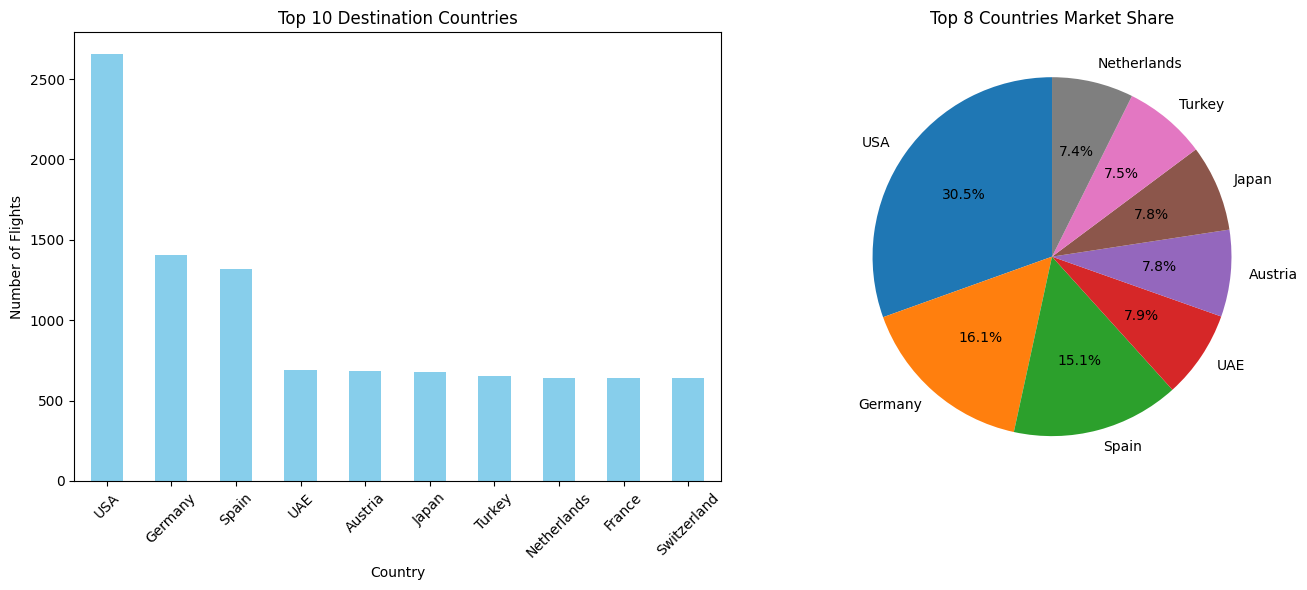


 Visualization saved to 'destination_analysis.png'


In [4]:
# Flights Per Destination Country
def analyze_destinations(df, visualize=True):
    
    print("\n" + "=" * 60)
    print("✈️  DESTINATION COUNTRY ANALYSIS")
    print("=" * 60)
    
    # Basic statistics
    total_flights = len(df)
    unique_countries = df['ARRIVAL_COUNTRY'].nunique()
    
    print(f"\n Summary:")
    print(f"  Total flights: {total_flights:,}")
    print(f"  Unique destinations: {unique_countries}")
    
    # Get counts
    counts = df['ARRIVAL_COUNTRY'].value_counts()
    
    print(f"\n Flights per Destinations Country:")
    print("-" * 50)
    
    for i, (country, count) in enumerate(counts.head(10).items(), 1):
        percentage = (count / total_flights) * 100
        bar = '█' * int(percentage / 2)  # Scale for display
        print(f"{i:2}. {country:<25} {count:>8,} ({percentage:>5.1f}%) {bar}")

    
    # Find most and least popular
    print(f"\n Most popular: {counts.index[0]} ({counts.iloc[0]:,} flights)")
    print(f" Least popular: {counts.index[-1]} ({counts.iloc[-1]:,} flights)")
    
    # Optional visualization
    if visualize:
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            
            # Bar chart
            counts.head(10).plot(kind='bar', ax=ax1, color='skyblue')
            ax1.set_title('Top 10 Destination Countries')
            ax1.set_xlabel('Country')
            ax1.set_ylabel('Number of Flights')
            ax1.tick_params(axis='x', rotation=45)
            
            # Pie chart
            counts.head(8).plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Top 8 Countries Market Share')
            ax2.set_ylabel('')
            
            plt.tight_layout()
            plt.savefig('flights_per_destination.png', dpi=150)
            plt.show()
            
            print("\n Visualization saved to 'destination_analysis.png'")
            
        except ImportError:
            print("\n matplotlib not installed for visualization")
    
    return counts

# Usage
destination_counts = analyze_destinations(df)


✈️  FLIGHTS PER REGION ANALYSIS

 Summary:
  Total flights: 10,000
  Regions flown to: 4

 Flights per Region:
--------------------------------------------------

 Most popular region is Europe with 5,975 flights
 Least popular region is Asia with 679 flights
 1. Europe                       5,975 ( 59.8%) █████████████████████████████
 2. North America                2,658 ( 26.6%) █████████████
 3. Middle East                    688 (  6.9%) ███
 4. Asia                           679 (  6.8%) ███


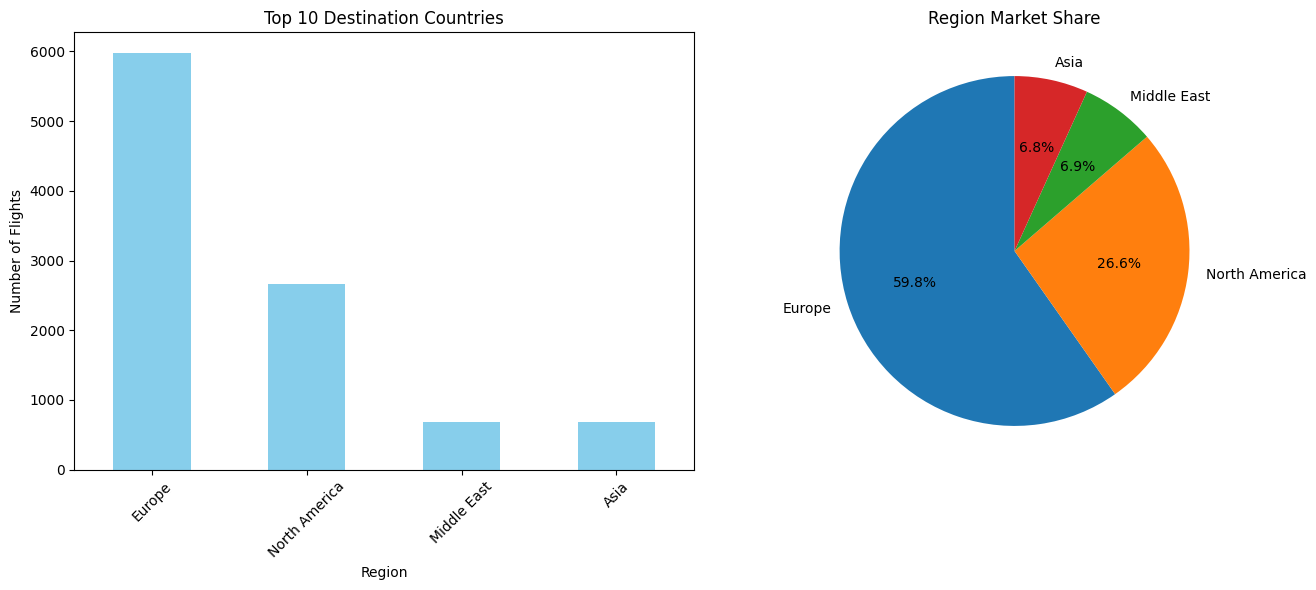


 Visualization saved to 'flights_per_region.png'


In [5]:
# Flights per region (Europe vs North America etc.)
def flights_per_region(df, visualize=True):
    
    print("\n" + "=" * 60)
    print("✈️  FLIGHTS PER REGION ANALYSIS")
    print("=" * 60)
    
    # Basic statistics
    total_flights = len(df)
    regions = df['ARRIVAL_REGION'].nunique()
    
    print(f"\n Summary:")
    print(f"  Total flights: {total_flights:,}")
    print(f"  Regions flown to: {regions}")

    counts = df['ARRIVAL_REGION'].value_counts()
    
    print(f"\n Flights per Region:")
    print("-" * 50)

    print(f"\n Most popular region is {counts.index[0]} with {counts.iloc[0]:,} flights")
    print(f" Least popular region is {counts.index[-1]} with {counts.iloc[-1]:,} flights")

    for i, (region, count) in enumerate(counts.head(10).items(), 1):
        percentage = (count / total_flights) * 100
        bar = '█' * int(percentage / 2)  # Scale for display
        print(f"{i:2}. {region:<25} {count:>8,} ({percentage:>5.1f}%) {bar}")
    
    if visualize:
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            
            # Bar chart
            counts.head(10).plot(kind='bar', ax=ax1, color='skyblue')
            ax1.set_title('Top 10 Destination Countries')
            ax1.set_xlabel('Region')
            ax1.set_ylabel('Number of Flights')
            ax1.tick_params(axis='x', rotation=45)
            
            # Pie chart
            counts.head(8).plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Region Market Share')
            ax2.set_ylabel('')
            
            plt.tight_layout()
            plt.savefig('flights_per_region.png', dpi=150)
            plt.show()
            
            print("\n Visualization saved to 'flights_per_region.png'")
            
        except ImportError:
            print("\n matplotlib not installed for visualization")
    
    return counts


region_counts = flights_per_region(df)


✈️  FLIGHTS PER AIRCRAFT TYPE ANALYSIS

 Summary:
  Total flights: 10,000
  Aircraft Types: 5

 Flights per Aircraft
--------------------------------------------------

 Most popular aircraft type is A320 with 5,975.
 Least popular aircraft type is A380 with 376.
 1. A320                         5,975 ( 59.8%) █████████████████████████████
 2. B777                         1,878 ( 18.8%) █████████
 3. B787                         1,236 ( 12.4%) ██████
 4. A350                           535 (  5.3%) ██
 5. A380                           376 (  3.8%) █


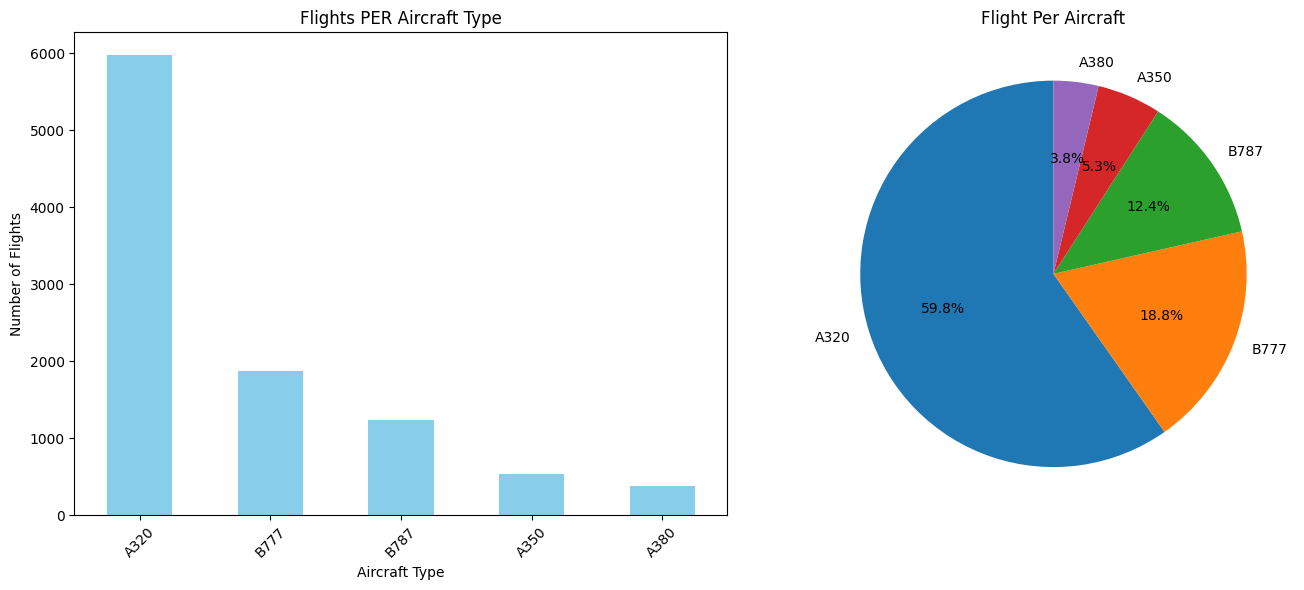


 Visualization saved to 'flights_per_aircraft_type.png'


In [6]:
# Flights per aircraft type
def flights_per_aircraft(df, visualize=True):
    
    print("\n" + "=" * 60)
    print("✈️  FLIGHTS PER AIRCRAFT TYPE ANALYSIS")
    print("=" * 60)
    
    # Basic statistics
    total_flights = len(df)
    aircraft_type = df['AIRCRAFT_TYPE'].nunique()
    
    print(f"\n Summary:")
    print(f"  Total flights: {total_flights:,}")
    print(f"  Aircraft Types: {aircraft_type}")

    counts = df['AIRCRAFT_TYPE'].value_counts()
    
    print(f"\n Flights per Aircraft")
    print("-" * 50)

    print(f"\n Most popular aircraft type is {counts.index[0]} with {counts.iloc[0]:,}.")
    print(f" Least popular aircraft type is {counts.index[-1]} with {counts.iloc[-1]:,}.")

    for i, (region, count) in enumerate(counts.head(10).items(), 1):
        percentage = (count / total_flights) * 100
        bar = '█' * int(percentage / 2)  # Scale for display
        print(f"{i:2}. {region:<25} {count:>8,} ({percentage:>5.1f}%) {bar}")
    
    if visualize:
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            
            # Bar chart
            counts.head(10).plot(kind='bar', ax=ax1, color='skyblue')
            ax1.set_title('Flights PER Aircraft Type')
            ax1.set_xlabel('Aircraft Type')
            ax1.set_ylabel('Number of Flights')
            ax1.tick_params(axis='x', rotation=45)
            
            # Pie chart
            counts.head(8).plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Flight Per Aircraft')
            ax2.set_ylabel('')
            
            plt.tight_layout()
            plt.savefig('flights_per_aircraft_type.png', dpi=150)
            plt.show()
            
            print("\n Visualization saved to 'flights_per_aircraft_type.png'")
            
        except ImportError:
            print("\n matplotlib not installed for visualization")
    
    return counts


aircrfat_type_counts = flights_per_aircraft(df)


✈️  FLIGHTS BY TIME OF DAY ANALYSIS

 Summary:
  Total flights: 10,000
  Aircraft Types: 4

 Flights per Aircraft
--------------------------------------------------

 Most popular travelling time of the day is Morning with 3,530 flights.
 Least popular travelling time of the day is Lunchtime with 1,192 flights.
 1. Morning                      3,530 ( 35.3%) █████████████████
 2. Evening                      2,973 ( 29.7%) ██████████████
 3. Afternoon                    2,305 ( 23.1%) ███████████
 4. Lunchtime                    1,192 ( 11.9%) █████


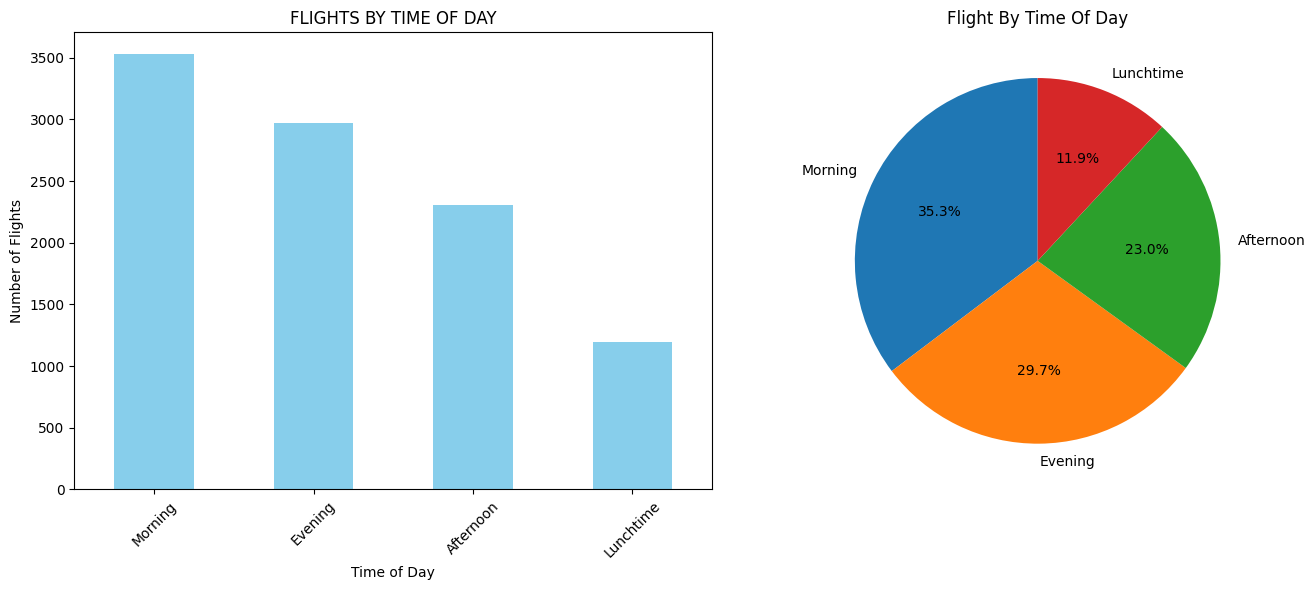


 Visualization saved to 'flights_by_time_of_day.png'


In [7]:
# Flights by time of day
def flights_by_time_of_day(df, visualize=True):
    
    print("\n" + "=" * 60)
    print("✈️  FLIGHTS BY TIME OF DAY ANALYSIS")
    print("=" * 60)
    
    # Basic statistics
    total_flights = len(df)
    time_of_day = df['TIME_OF_DAY'].nunique()
    
    print(f"\n Summary:")
    print(f"  Total flights: {total_flights:,}")
    print(f"  Aircraft Types: {time_of_day}")

    counts = df['TIME_OF_DAY'].value_counts()
    
    print(f"\n Flights per Aircraft")
    print("-" * 50)

    print(f"\n Most popular travelling time of the day is {counts.index[0]} with {counts.iloc[0]:,} flights.")
    print(f" Least popular travelling time of the day is {counts.index[-1]} with {counts.iloc[-1]:,} flights.")

    for i, (region, count) in enumerate(counts.head(10).items(), 1):
        percentage = (count / total_flights) * 100
        bar = '█' * int(percentage / 2)  # Scale for display
        print(f"{i:2}. {region:<25} {count:>8,} ({percentage:>5.1f}%) {bar}")
    
    if visualize:
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            
            # Bar chart
            counts.head(10).plot(kind='bar', ax=ax1, color='skyblue')
            ax1.set_title('FLIGHTS BY TIME OF DAY')
            ax1.set_xlabel('Time of Day')
            ax1.set_ylabel('Number of Flights')
            ax1.tick_params(axis='x', rotation=45)
            
            # Pie chart
            counts.head(8).plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Flight By Time Of Day')
            ax2.set_ylabel('')
            
            plt.tight_layout()
            plt.savefig('flights_by_time_of_day.png', dpi=150)
            plt.show()
            
            print("\n Visualization saved to 'flights_by_time_of_day.png'")
            
        except ImportError:
            print("\n matplotlib not installed for visualization")
    
    return counts


flights_by_time_of_day_count = flights_by_time_of_day(df)


✈️  FLIGHTS PER MONTH ANALYSIS

 Summary:
  Total flights: 10,000
  Months: 7

 Flights per Month
--------------------------------------------------

 Most popular travelling month is May with 1,488 flights.
 Least popular travelling month is October with 1,345 flights.
 1. May                          1,488 ( 14.9%) ███████
 2. June                         1,483 ( 14.8%) ███████
 3. April                        1,436 ( 14.4%) ███████
 4. September                    1,430 ( 14.3%) ███████
 5. August                       1,429 ( 14.3%) ███████
 6. July                         1,389 ( 13.9%) ██████
 7. October                      1,345 ( 13.5%) ██████


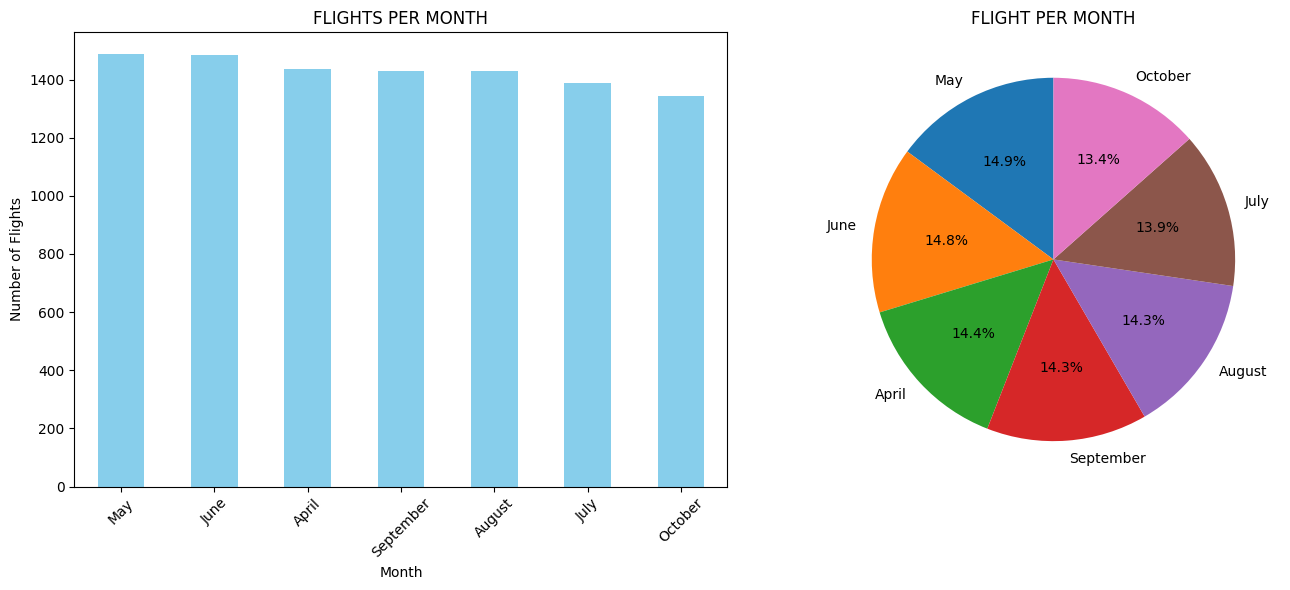


 Visualization saved to 'flights_per_month.png'


In [8]:
# Flights per month
def flights_per_month(df, visualize=True):
    
    print("\n" + "=" * 60)
    print("✈️  FLIGHTS PER MONTH ANALYSIS")
    print("=" * 60)
    
    # Basic statistics
    total_flights = len(df)
    months = pd.to_datetime(df['FLIGHT_DATE']).dt.month_name().nunique()
    
    print(f"\n Summary:")
    print(f"  Total flights: {total_flights:,}")
    print(f"  Months: {months}")

    counts = pd.to_datetime(df['FLIGHT_DATE']).dt.month_name().value_counts()
    
    print(f"\n Flights per Month")
    print("-" * 50)

    print(f"\n Most popular travelling month is {counts.index[0]} with {counts.iloc[0]:,} flights.")
    print(f" Least popular travelling month is {counts.index[-1]} with {counts.iloc[-1]:,} flights.")

    for i, (month, count) in enumerate(counts.head(10).items(), 1):
        percentage = (count / total_flights) * 100
        bar = '█' * int(percentage / 2)  # Scale for display
        print(f"{i:2}. {month:<25} {count:>8,} ({percentage:>5.1f}%) {bar}")
    
    if visualize:
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            
            # Bar chart
            counts.head(10).plot(kind='bar', ax=ax1, color='skyblue')
            ax1.set_title('FLIGHTS PER MONTH')
            ax1.set_xlabel('Month')
            ax1.set_ylabel('Number of Flights')
            ax1.tick_params(axis='x', rotation=45)
            
            # Pie chart
            counts.head(8).plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
            ax2.set_title('FLIGHT PER MONTH')
            ax2.set_ylabel('')
            
            plt.tight_layout()
            plt.savefig('flights_per_month.png', dpi=150)
            plt.show()
            
            print("\n Visualization saved to 'flights_per_month.png'")
            
        except ImportError:
            print("\n matplotlib not installed for visualization")
    
    return counts

flights_per_month_count = flights_per_month(df)

✈️ TOP 10 BUSIEST ROUTES

Summary:
------------------------------------------------------------
Total flights: 10,000
Most popular route is LHR → FRA with 714 flights.
Least popular route is LHR → ZRH with 638 flights.
------------------------------------------------------------

Route                     Number of Flights    Percentage          
------------------------------------------------------------
 1. LHR → FRA                      714 (  7.1%) ███
 2. LHR → MUC                      691 (  6.9%) ███
 3. LHR → DXB                      688 (  6.9%) ███
 4. LHR → VIE                      682 (  6.8%) ███
 5. LHR → HND                      679 (  6.8%) ███
 6. LHR → ORD                      675 (  6.8%) ███
 7. LHR → MAD                      673 (  6.7%) ███
 8. LHR → LAX                      666 (  6.7%) ███
 9. LHR → JFK                      664 (  6.6%) ███
10. LHR → DFW                      653 (  6.5%) ███


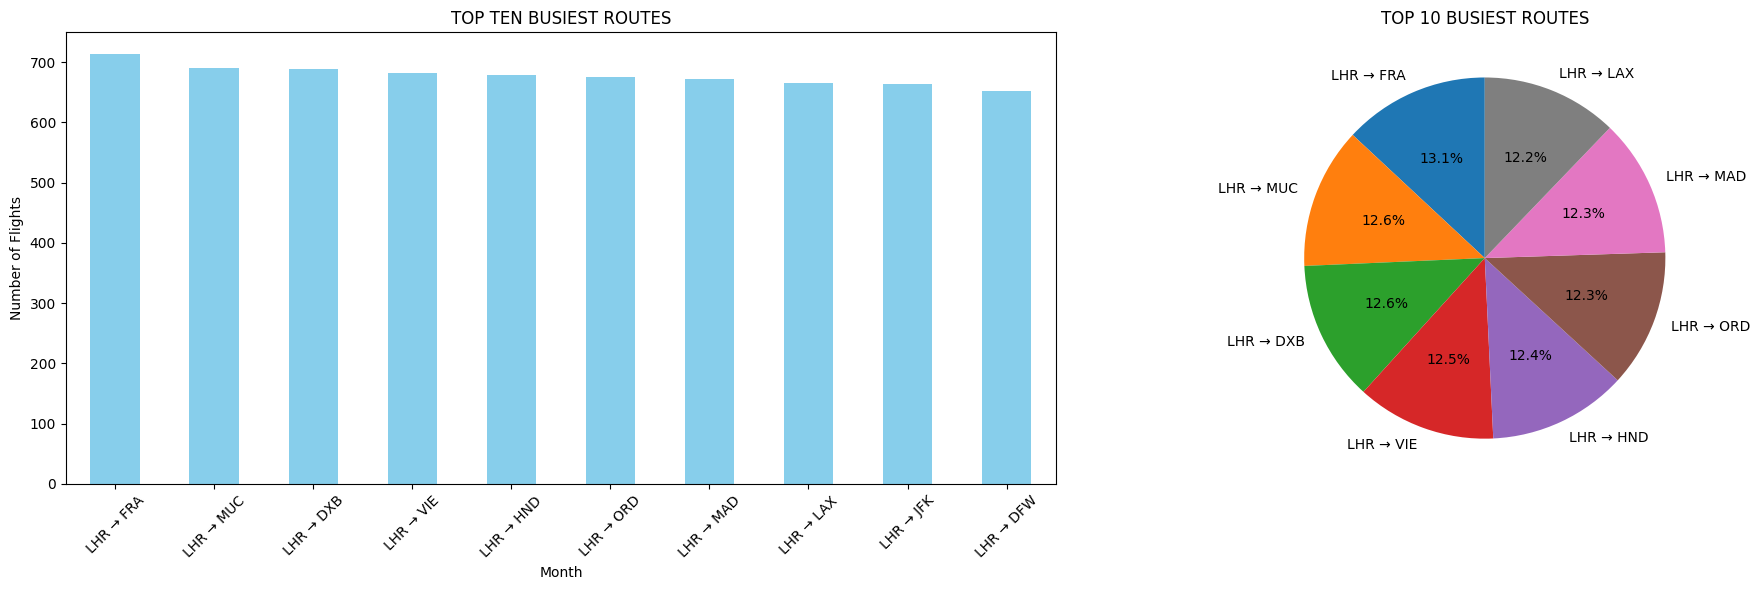


 Visualization saved to 'top_ten_busiest_routes.png'


In [9]:
# Create a route column by combining origin and destination
def flight_per_route(df, visualize=True):
    print("=" * 60)
    print("✈️ TOP 10 BUSIEST ROUTES")
    print("=" * 60)

    df['ROUTE'] = df['DEPARTURE_STATION_CD'] + ' → ' + df['ARRIVAL_STATION_CD']

    counts = df['ROUTE'].value_counts()

    total_flights = len(df)


    print(f"\nSummary:")
    print("-" * 60)
    print(f"Total flights: {total_flights:,}")
    print(f"Most popular route is {counts.index[0]} with {counts.iloc[0]:,} flights.")
    print(f"Least popular route is {counts.index[-1]} with {counts.iloc[-1]:,} flights.")


    print("-" * 60)

    print(f"\n{'Route':<25} {'Number of Flights':<20} {'Percentage':<20}")

    print("-" * 60)
    for i, (r, count) in enumerate(counts.head(10).items(), 1):
        percentage = (count / total_flights) * 100
        bar = '█' * int(percentage / 2)  
        print(f"{i:2}. {r:<25} {count:>8,} ({percentage:>5.1f}%) {bar}")
    
    if visualize:
        try:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
            
            # Bar chart
            counts.head(10).plot(kind='bar', ax=ax1, color='skyblue')
            ax1.set_title('TOP TEN BUSIEST ROUTES')
            ax1.set_xlabel('Month')
            ax1.set_ylabel('Number of Flights')
            ax1.tick_params(axis='x', rotation=45)
            
            # Pie chart
            counts.head(8).plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
            ax2.set_title('TOP 10 BUSIEST ROUTES')
            ax2.set_ylabel('')
            
            plt.tight_layout()
            plt.savefig('top_ten_busiest_routes.png', dpi=150)
            plt.show()
            
            print("\n Visualization saved to 'top_ten_busiest_routes.png'")
            
        except ImportError:
            print("\n matplotlib not installed for visualization")
    
    return counts
flights_per_route = flight_per_route(df)



In [10]:
# routes = {
#     "FRA": "Frankfurt",
#     "MUN": "Munich",
#     "DXB": "Dubai",
#     "VIE": "Vienna",
#     "HND": "Haneda",
#     "ORD": "Chicago",
#     "MAD": "Madrid",
#     "LAX": "Los Angeles",
#     "JFK": "New York",
#     "DFW": "Dallas",
#     "IST": "Istanbul",
#     "BCN": "Barcelona",
#     "AMS": "Amsterdam",
#     "CDG": "Paris",
#     "ZRH": "Zurich",
#     "LHR": "Heathrow"
# }

df['ROUTE'] = df['DEPARTURE_STATION_CD'] + ' → ' + df['ARRIVAL_STATION_CD']
df['ROUTE'].value_counts()


ROUTE
LHR → FRA    714
LHR → MUC    691
LHR → DXB    688
LHR → VIE    682
LHR → HND    679
LHR → ORD    675
LHR → MAD    673
LHR → LAX    666
LHR → JFK    664
LHR → DFW    653
LHR → IST    650
LHR → BCN    645
LHR → AMS    641
LHR → CDG    641
LHR → ZRH    638
Name: count, dtype: int64

In [11]:
df['ARRIVAL_REGION'].value_counts()

ARRIVAL_REGION
Europe           5975
North America    2658
Middle East       688
Asia              679
Name: count, dtype: int64

In [12]:
columns = ['FIRST_CLASS_SEATS', 'BUSINESS_CLASS_SEATS', 'ECONOMY_SEATS', 'TIER1_ELIGIBLE_PAX', 'TIER2_ELIGIBLE_PAX', 'TIER3_ELIGIBLE_PAX']
df['TOTAL_SEATS'] = df[columns[0]] + df[columns[1]] + df[columns[2]]
df['TOTAL_TIER_ELIGIBLE'] = df[columns[3]] + df[columns[4]] + df[columns[5]]
df.head()

,FLIGHT_DATE,FLIGHT_TIME,TIME_OF_DAY,AIRLINE_CD,FLIGHT_NO,DEPARTURE_STATION_CD,ARRIVAL_STATION_CD,ARRIVAL_COUNTRY,ARRIVAL_REGION,HAUL,AIRCRAFT_TYPE,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX,ROUTE,TOTAL_SEATS,TOTAL_TIER_ELIGIBLE
0,2025-09-02,14:19:00,Afternoon,BA,BA5211,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,10,38,LHR → LAX,235,48
1,2025-06-10,06:42:00,Morning,BA,BA7282,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,7,28,LHR → LAX,235,35
2,2025-10-27,15:33:00,Afternoon,BA,BA1896,LHR,FRA,Germany,Europe,SHORT,A320,0,17,163,0,11,40,LHR → FRA,180,51
3,2025-06-15,18:29:00,Evening,BA,BA5497,LHR,IST,Turkey,Europe,SHORT,A320,0,8,172,0,16,54,LHR → IST,180,70
4,2025-08-25,20:35:00,Evening,BA,BA1493,LHR,FRA,Germany,Europe,SHORT,A320,0,13,167,0,6,27,LHR → FRA,180,33


In [13]:
df['ROUTE'] = df['DEPARTURE_STATION_CD'] + ' → ' + df['ARRIVAL_STATION_CD']
columns = ['ROUTE', 'HAUL', 'AIRCRAFT_TYPE']
df[columns].head()

,ROUTE,HAUL,AIRCRAFT_TYPE
0,LHR → LAX,LONG,B777
1,LHR → LAX,LONG,B777
2,LHR → FRA,SHORT,A320
3,LHR → IST,SHORT,A320
4,LHR → FRA,SHORT,A320


In [14]:
# "Region + Haul + Time Window"
region_route_type_and_time = ['HAUL', 'TIME_OF_DAY', 'ROUTE', 'AIRCRAFT_TYPE', 'ARRIVAL_REGION']
df[region_route_type_and_time].sample(n=10)

,HAUL,TIME_OF_DAY,ROUTE,AIRCRAFT_TYPE,ARRIVAL_REGION
3542,LONG,Afternoon,LHR → LAX,B787,North America
7954,LONG,Morning,LHR → DFW,B777,North America
8580,SHORT,Morning,LHR → FRA,A320,Europe
6221,SHORT,Morning,LHR → AMS,A320,Europe
7107,SHORT,Evening,LHR → CDG,A320,Europe
6435,SHORT,Morning,LHR → VIE,A320,Europe
3996,SHORT,Evening,LHR → VIE,A320,Europe
4256,LONG,Lunchtime,LHR → ORD,B777,North America
8458,LONG,Evening,LHR → HND,B787,Asia
3205,SHORT,Morning,LHR → AMS,A320,Europe


In [21]:
# We look for rows where HAUL is 'LONG' and TIME_OF_DAY is 'Morning'
long_haul_morning = df[(df['HAUL'] == 'SHORT') & (df['TIME_OF_DAY'] == 'Evening')]

# Extract unique destinations and their corresponding countries
destinations = long_haul_morning[['ROUTE']].drop_duplicates()

print("Example Destinations for Long-Haul Morning Flights:")
print(destinations)

Example Destinations for Long-Haul Morning Flights:
         ROUTE
3    LHR → IST
4    LHR → FRA
5    LHR → VIE
6    LHR → AMS
15   LHR → CDG
24   LHR → MUC
26   LHR → MAD
69   LHR → BCN
127  LHR → ZRH
